# Goal: Inspect the period distributions 
### of all system classes, as well as evolutionionary similar systems

(LvS: 05-02-26)

In [43]:
import json
import numpy as np
import pandas as pd
import sys, os

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

from scipy.stats import gaussian_kde

from pathlib import Path

# Ensure project root is on sys.path so `import paths` finds the top-level paths.py
proj_root = Path('/Users/liekevanson/Documents/Projects/post_mt_review').resolve()
if str(proj_root) not in sys.path:
    sys.path.insert(0, str(proj_root))

from paths import DUMMY_CATALOG, MAIN_CATALOG, PLOTS_DIR, DOCS_DIR, LATEX_PLOT_DIR

file_path = MAIN_CATALOG


# Use mathtext (LaTeX-like without needing LaTeX)
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['DejaVu Serif', 'Computer Modern Roman']
plt.rcParams['mathtext.fontset'] = 'cm'  # Computer Modern math font
plt.rcParams['font.size'] = 12


### Read json catalog into pandas table

In [44]:
# === Load JSON ===
def read_json_file(file_path):
    try:
        with open(file_path, "r") as f:
            data = json.load(f)
        return data
    except Exception as e:
        print(f"Error reading file: {e}")
        return None

def extract_triplet_array(data, key):
    """Return an (N,3) float array for the given triplet key, robust to None/NaN."""
    rows = []
    for entry in data:
        val = entry.get(key, None)
        if isinstance(val, (list, tuple, np.ndarray)) and len(val) == 3:
            try:
                # Convert None to np.nan before float conversion
                rows.append([
                    np.nan if val[0] is None else float(val[0]),
                    np.nan if val[1] is None else float(val[1]),
                    np.nan if val[2] is None else float(val[2])
                ])
            except (TypeError, ValueError):
                rows.append([np.nan, np.nan, np.nan])
        elif isinstance(val, (int, float)):
            # Scalar provided, treat as central value with unknown errors
            rows.append([np.nan, float(val), np.nan])
        else:
            rows.append([np.nan, np.nan, np.nan])
    return np.array(rows, dtype=float)

In [45]:
# Read data
data = read_json_file(str(MAIN_CATALOG))
if data is None:
    print("No data loaded. Exiting.")
    exit(1)


In [46]:
# Extract triplet columns once for efficiency/consistency
RA_arr = extract_triplet_array(data, 'RA')
Dec_arr = extract_triplet_array(data, 'Dec')
period_arr = extract_triplet_array(data, 'Period')
ecc_arr = extract_triplet_array(data, 'Eccentricity')
m1_arr = extract_triplet_array(data, 'M1')
m2_arr = extract_triplet_array(data, 'M2')

# Build a single DataFrame with central values and errors
catalog_df = pd.DataFrame({
    'System Name': [entry.get('System Name', '') for entry in data],
    'RA': RA_arr[:, 1],
    'Dec': Dec_arr[:, 1],
    'Period': period_arr[:, 1],
    'Period_err_minus': period_arr[:, 0],
    'Period_err_plus': period_arr[:, 2],
    'Eccentricity': ecc_arr[:, 1],
    'Eccentricity_err_minus': ecc_arr[:, 0],
    'Eccentricity_err_plus': ecc_arr[:, 2],
    'M1': m1_arr[:, 1],
    'M1_err_minus': m1_arr[:, 0],
    'M1_err_plus': m1_arr[:, 2],
    'M2': m2_arr[:, 1],
    'M2_err_minus': m2_arr[:, 0],
    'M2_err_plus': m2_arr[:, 2],
    'obs_type_1': [entry.get('obs_type_1', '') for entry in data],
    'obs_type_2': [entry.get('obs_type_2', '') for entry in data],
    'evol_type_1': [entry.get('evol_type_1', '') for entry in data],
    'evol_type_2': [entry.get('evol_type_2', '') for entry in data],
    'system_class': [entry.get('system_class', 'None') for entry in data],
    'Simbad': [entry.get('Simbad', None) for entry in data]
})

In [47]:
display(catalog_df)

,System Name,RA,Dec,Period,Period_err_minus,Period_err_plus,Eccentricity,Eccentricity_err_minus,Eccentricity_err_plus,M1,...,M1_err_plus,M2,M2_err_minus,M2_err_plus,obs_type_1,obs_type_2,evol_type_1,evol_type_2,system_class,Simbad
0,Cl* NGC 188 PKM 451,8.700020,85.540940,722.000000,4.000000e+00,4.000000e+00,0.34,0.03,0.03,NaN,...,NaN,NaN,NaN,NaN,None,None,MS,WD,Blue straggler binary,https://simbad.cds.unistra.fr/simbad/sim-coo?C...
1,Cl* NGC 188 PKM 1888,13.631330,85.535900,2240.000000,3.000000e+01,3.000000e+01,0.21,0.04,0.04,NaN,...,NaN,NaN,NaN,NaN,None,None,MS,WD,Blue straggler binary,https://simbad.cds.unistra.fr/simbad/sim-coo?C...
2,Cl* NGC 188 PKM 2679,6.685930,85.310000,1033.000000,8.000000e+00,8.000000e+00,0.07,0.05,0.05,NaN,...,NaN,NaN,NaN,NaN,None,None,MS,WD,Blue straggler binary,https://simbad.cds.unistra.fr/simbad/sim-coo?C...
3,Cl* NGC 188 PKM 4348,10.923210,85.221480,1168.000000,8.000000e+00,8.000000e+00,0.09,0.05,0.05,NaN,...,NaN,NaN,NaN,NaN,None,None,MS,WD,Blue straggler binary,https://simbad.cds.unistra.fr/simbad/sim-coo?C...
4,Cl* NGC 188 PKM 4540,11.326540,85.322200,3030.000000,7.000000e+01,7.000000e+01,0.36,0.07,0.07,NaN,...,NaN,NaN,NaN,NaN,None,None,MS,WD,Blue straggler binary,https://simbad.cds.unistra.fr/simbad/sim-coo?C...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4748,UCAC4 495-142916,297.473341,8.904363,0.748668,1.600000e-06,1.600000e-06,NaN,NaN,NaN,1.69,...,0.07,0.31,0.07,0.07,None,pre-He WD,MS,WD,EL CVn,https://simbad.cds.unistra.fr/simbad/sim-coo?C...
4749,CRTS J225539.4+342138,118.713529,34.360512,0.571785,3.000000e-07,3.000000e-07,NaN,NaN,NaN,1.40,...,0.04,0.26,0.04,0.04,None,pre-He WD,MS,WD,EL CVn,https://simbad.cds.unistra.fr/simbad/sim-coo?C...
4750,UCAC4 646-116578,123.282814,39.139678,0.766129,3.800000e-06,3.800000e-06,NaN,NaN,NaN,1.60,...,0.08,0.16,0.05,0.05,None,pre-He WD,MS,WD,EL CVn,https://simbad.cds.unistra.fr/simbad/sim-coo?C...
4751,ZTF J225755.64+310133.7,127.228463,31.026046,0.688416,4.000000e-07,4.000000e-07,NaN,NaN,NaN,1.65,...,0.06,0.29,0.04,0.04,None,pre-He WD,MS,WD,EL CVn,https://simbad.cds.unistra.fr/simbad/sim-coo?C...


In [48]:
# System-class colours and symbols — imported from the shared module.
# Edit code/data_analysis/Category_dict.py to change colours/symbols everywhere.
import importlib

from Category_dict import SYSTEM_CLASS_MAP, STYLE_MAP, COLORMAP, SYMBOLMAP
importlib.reload(sys.modules['Category_dict'])  # Ensure we have the latest version of the dict after edits

<module 'Category_dict' from '/Users/liekevanson/Documents/Projects/post_mt_review/code/data_analysis/Category_dict.py'>

# Plot the period distribution

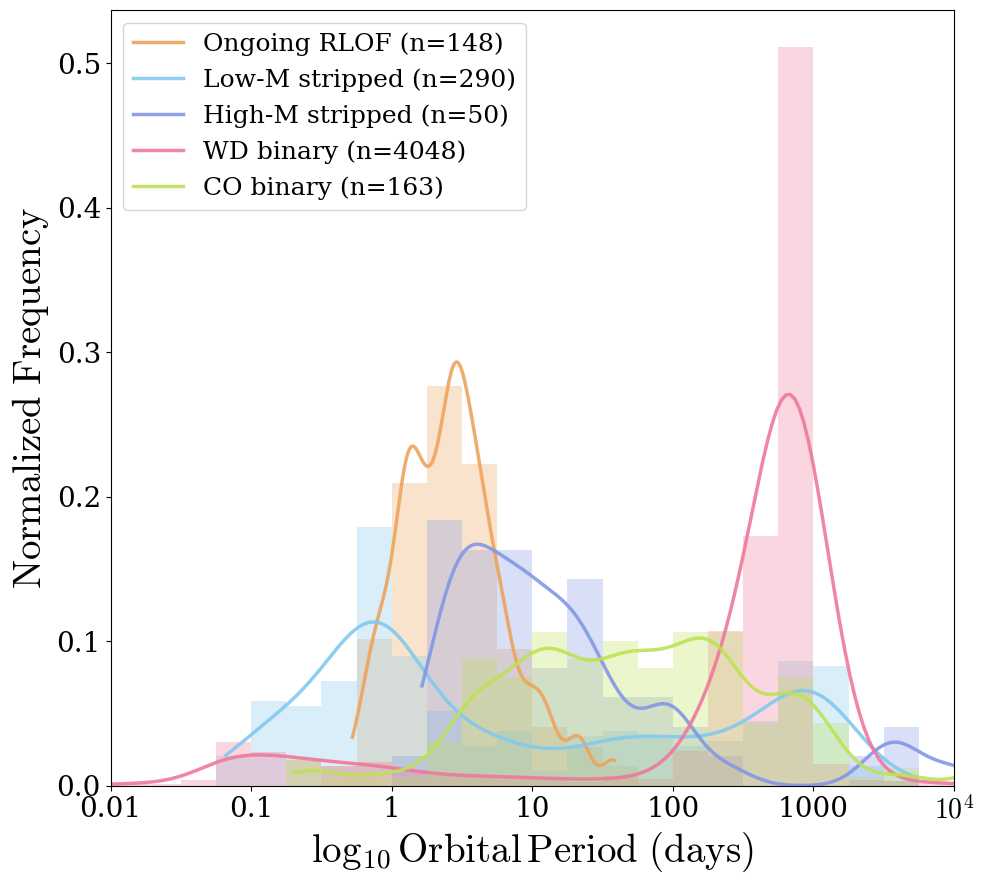

unique system_classes in catalog df ['Algol' 'Astrometric WD + MS' 'Astrometric compact object'
 'Blue straggler binary' 'Chemically Peculiar' 'Contact binary' 'EL CVn'
 'He giant' 'Hot subdwarf binary' 'Intermediate-M stripped star'
 'Post-AGB binary' 'Self-lensing WD + MS' 'Spectroscopic WD + MS'
 'Spectroscopic compact object' 'Symbiotic XRB' 'WD + MS' 'WR binary'
 'high-mass XRB' 'pulsar binary']
system_classes in dict [['Algol', 'Contact binary'], ['Hot subdwarf binary', 'He giant', 'Post-AGB binary', 'EL CVn'], ['Intermediate-M stripped star', 'WR binary'], ['Blue straggler binary', 'Chemically Peculiar', 'Self-lensing WD + MS', 'Spectroscopic WD + MS', 'Astrometric WD + MS', 'WD + MS'], ['pulsar binary', 'high-mass XRB', 'Symbiotic XRB', 'Spectroscopic compact object', 'Astrometric compact object']]


In [49]:
# Define histogram bins
bins = np.linspace(-2, 4, 25)
bin_width = bins[1] - bins[0]

sys_classes_in_dict = []

fig, ax = plt.subplots(figsize=(10, 9))
# Loop over categories instead of individual system classes
for category, systems in SYSTEM_CLASS_MAP.items():
    
    # Combine all system classes in this category
    system_classes_in_category = list(systems.keys())
    sys_classes_in_dict.append(system_classes_in_category)
    subset = catalog_df[catalog_df['system_class'].isin(system_classes_in_category)]
    log_periods = np.log10(subset['Period'].dropna())
    
    if len(log_periods) > 1:
        # Compute histogram counts
        counts, bin_edges = np.histogram(log_periods, bins=bins)
        
        # Normalize by total count
        counts_normalized = counts / counts.sum()
        
        # Plot histogram as bar chart (use first system's color as category color)
        first_system_color = list(systems.values())[0]['color']
        bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
        plt.bar(bin_centers, counts_normalized, width=bin_width, alpha=0.3, 
                color=first_system_color, edgecolor='none')
        
        # Plot KDE on top (also normalized)
        kde = gaussian_kde(log_periods,bw_method = 0.2)# bw_method='scott')
        x_range = np.linspace(log_periods.min(), log_periods.max(), 200)
        kde_values = kde(x_range)
        
        # Scale KDE to match normalized histogram
        kde_normalized = kde_values * bin_width
        
        plt.plot(x_range, kde_normalized, color=first_system_color, linewidth=2.5, 
                label=f"{category} (n={len(log_periods)})", alpha=0.9)

# Write x ticks not in log space but in days
xticks = [0.01, 0.1, 1, 10, 100, 1000, 10000]
xtick_labels = ['0.01', '0.1', '1', '10', '100', '1000', '$10^4$']
plt.xticks(np.log10(xticks), xtick_labels, fontsize=20) 

# Plot formatting
# Set tick labels to be larger and use mathtext for the x-axis
plt.xlim(-2,4)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
plt.xlabel('$\log_{10} \mathrm{Orbital\,Period \ (days)}$', fontsize=28)
plt.ylabel('$\mathrm{Normalized \ Frequency}$', fontsize=28)
plt.legend(loc='upper left', fontsize=18)
plt.tight_layout()
plt.savefig(LATEX_PLOT_DIR / 'period_distribution_by_category.pdf')
plt.savefig(PLOTS_DIR / 'period_distribution_by_category.pdf')
plt.show()



print('unique system_classes in catalog df', np.unique(catalog_df['system_class']))
print('system_classes in dict', sys_classes_in_dict)